# Exploration des donnees

## 1. Chargement et preparation des donnees

Le jeu de donnees contient des mesures de tumeurs mammaires. La colonne `target` est recodee pour que `1` corresponde a une tumeur maligne et `0` a une tumeur benigne.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame

# sklearn utilise 0 pour malin et 1 pour benin; on inverse pour avoir 1 = malin.
df["target"] = 1 - df["target"]

## 2. Apercu des donnees

On affiche quelques lignes, les types de colonnes et les statistiques descriptives.

In [3]:
display(df.head())

df.info()

display(df.describe().T)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


## 3. Qualite et repartition des donnees

On verifie le nombre de valeurs manquantes et de lignes dupliquees.

In [4]:
missing_total = int(df.isna().sum().sum())
duplicate_total = int(df.duplicated().sum())

print(f"Valeurs manquantes : {missing_total}")
print(f"Lignes dupliquees : {duplicate_total}")

Valeurs manquantes : 0
Lignes dupliquees : 0


### Repartition des diagnostics

La classe `0` correspond a un diagnostic benin et la classe `1` a un diagnostic malin. Le tableau donne les effectifs et les proportions.

In [5]:
class_counts = df["target"].value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Nombre de cas": class_counts,
    "Proportion (%)": (class_counts / len(df) * 100).round(1),
})
class_distribution.index = class_distribution.index.map({0: "Benigne (0)", 1: "Maligne (1)"})

display(class_distribution)

,Nombre de cas,Proportion (%)
target,,
Benigne (0),357,62.7
Maligne (1),212,37.3


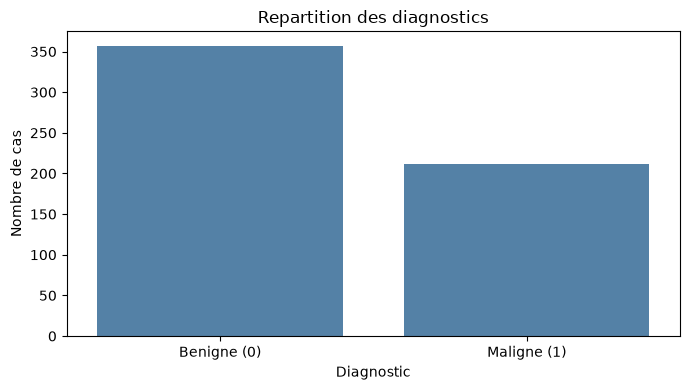

In [6]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="target", order=[0, 1], color="steelblue")
plt.xticks([0, 1], ["Benigne (0)", "Maligne (1)"])
plt.xlabel("Diagnostic")
plt.ylabel("Nombre de cas")
plt.title("Repartition des diagnostics")
plt.tight_layout()
plt.show()

## 4. Quels indices trahissent le coupable ? (variables vs cible)

Ces boxplots comparent trois variables selon le diagnostic. Si les boites sont bien separees et se chevauchent peu, la variable aide a distinguer les tumeurs benignes des tumeurs malignes. Un chevauchement important indique que cette variable seule distingue moins bien les classes.

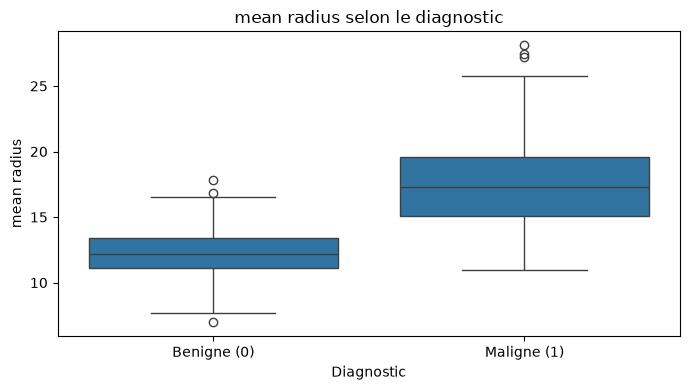

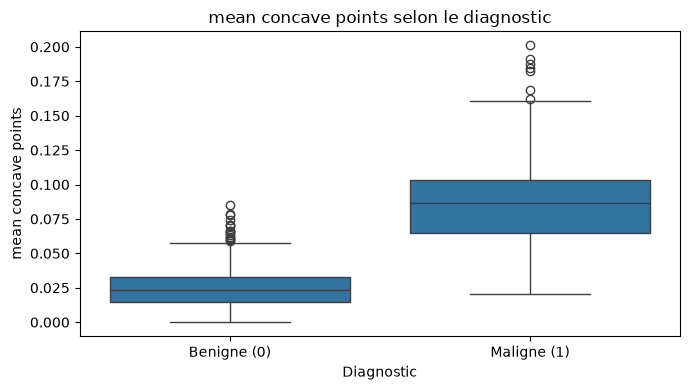

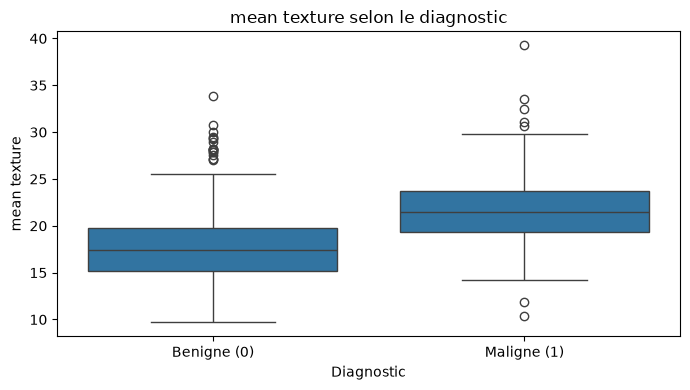

In [7]:
features_to_compare = ["mean radius", "mean concave points", "mean texture"]

for feature in features_to_compare:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x="target", y=feature, data=df, order=[0, 1])
    plt.xticks([0, 1], ["Benigne (0)", "Maligne (1)"])
    plt.xlabel("Diagnostic")
    plt.ylabel(feature)
    plt.title(f"{feature} selon le diagnostic")
    plt.tight_layout()
    plt.show()

## 5. Quels temoins disent la meme chose ? (correlations)

La matrice montre les correlations lineaires entre les variables et la cible. Des correlations fortes entre variables peuvent indiquer qu'elles apportent des informations similaires, sans prouver un lien de cause a effet.

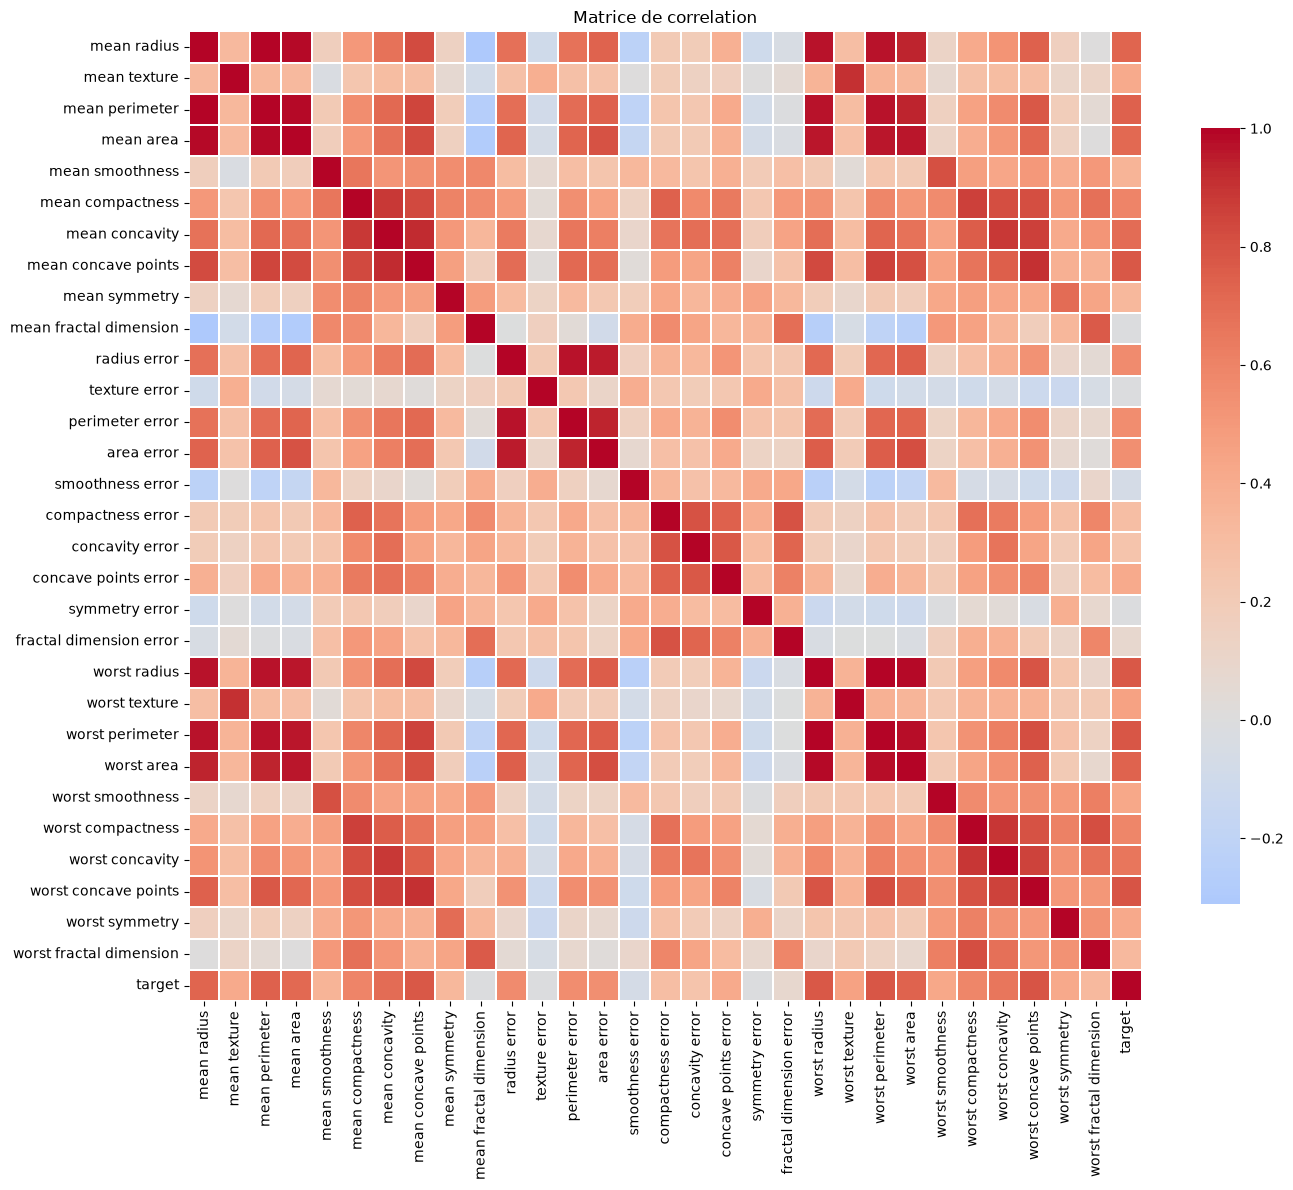

In [8]:
correlation = df.corr(numeric_only=True)

plt.figure(figsize=(14, 12))
sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8},
)
plt.title("Matrice de correlation")
plt.tight_layout()
plt.show()

Conclusion: 
Les données ne présentent ni valeurs manquantes ni doublons, mais les classes sont modérément déséquilibrées. Les mesures de rayon et de points concaves semblent distinguer les diagnostics plus nettement que la texture moyenne. Plusieurs variables sont fortement corrélées entre elles. Ces observations suggèrent que les données peuvent être utiles pour entraîner un perceptron, à condition de standardiser les variables et d’évaluer soigneusement sa capacité à détecter les cas malins.

## 6. Preparer, compresser, entrainer et evaluer

### 6.1. Separer les indices, les reponses et le test

- `X` contient les 30 mesures (les indices); `y` contient le diagnostic connu (la reponse).
- 80 % des exemples servent a apprendre; les 20 % restants servent de controle, comme un examen avec de nouvelles questions.
- `stratify=y` conserve approximativement la proportion de chaque diagnostic dans les deux groupes.
- `random_state=42` rend le tirage reproductible; 42 n'est pas un reglage qui rend le modele meilleur.

On retire `target` de `X` pour ne pas donner la reponse au modele.

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from perceptron import Perceptron

X = df.drop(columns="target").values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Apprentissage : {X_train.shape[0]} exemples, {X_train.shape[1]} mesures")
print(f"Test : {X_test.shape[0]} exemples, {X_test.shape[1]} mesures")

Apprentissage : 455 exemples, 30 mesures
Test : 114 exemples, 30 mesures


### 6.2. Mettre les mesures a une echelle comparable

`StandardScaler` recentre chaque mesure autour de 0 et ajuste sa dispersion. Cela facilite l'apprentissage du perceptron et evite qu'une mesure domine l'ACP uniquement parce que ses nombres sont grands.

`fit` apprend la moyenne et l'ecart-type sur l'apprentissage seulement; `transform` applique cette meme regle aux deux groupes. Le test ne doit pas servir a choisir cette regle. On ne standardise pas `y`.

In [13]:
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

print("Moyennes apres standardisation (5 premieres mesures) :")
print(np.round(X_train_s.mean(axis=0)[:5], 3))
print("Ecarts-types correspondants :")
print(np.round(X_train_s.std(axis=0)[:5], 3))

Moyennes apres standardisation (5 premieres mesures) :
[-0.  0. -0.  0.  0.]
Ecarts-types correspondants :
[1. 1. 1. 1. 1.]


### 6.3. Compresser avec l'ACP

L'ACP fabrique de nouveaux indices en melangeant les 30 mesures. Elle ne choisit pas simplement quelques colonnes originales.

`n_components=0.95` garde assez de composantes pour conserver au moins 95 % de la variance des mesures standardisees d'apprentissage. Ce n'est pas 95 % de bonnes predictions: l'ACP ne regarde pas les diagnostics pour fabriquer ses composantes.

Sur le graphique: l'axe horizontal compte les composantes; l'axe vertical indique la variance conservee en les additionnant. La ligne rouge marque 95 %. La courbe s'arrete au nombre de composantes retenu.

ACP : 30 mesures deviennent 10 composantes
Variance conservee : 95.2%


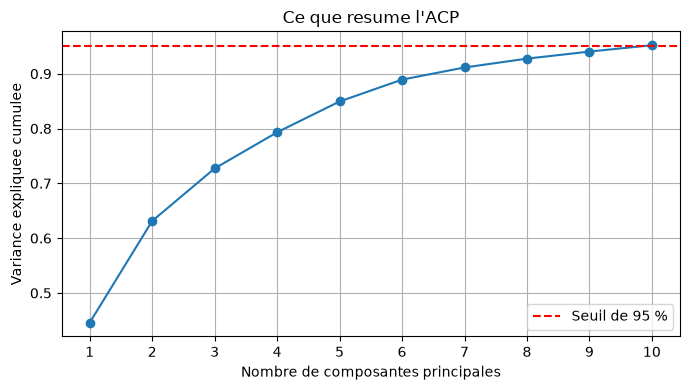

In [14]:
pca = PCA(n_components=0.95).fit(X_train_s)
X_train_p = pca.transform(X_train_s)
X_test_p = pca.transform(X_test_s)

variance_cumulee = np.cumsum(pca.explained_variance_ratio_)
n_composantes = np.arange(1, len(variance_cumulee) + 1)

print(f"ACP : {X_train_s.shape[1]} mesures deviennent {pca.n_components_} composantes")
print(f"Variance conservee : {variance_cumulee[-1]:.1%}")

plt.figure(figsize=(7, 4))
plt.plot(n_composantes, variance_cumulee, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="Seuil de 95 %")
plt.xticks(n_composantes)
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance expliquee cumulee")
plt.title("Ce que resume l'ACP")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 6.4. Entrainer deux perceptrons et predire

On compare le meme algorithme avec deux representations des memes exemples: les 30 mesures standardisees, puis les composantes de l'ACP.

- `fit` apprend les poids avec les indices et les diagnostics d'apprentissage.
- `learning_rate=0.01` regle la taille des corrections.
- `n_epochs=50` fait parcourir les exemples d'apprentissage 50 fois; cela ne garantit pas un apprentissage parfait.
- `predict` donne un diagnostic pour les exemples de test, sans recevoir leurs vraies reponses.

`np.mean(y_pred == y_test)` est la proportion totale de bonnes reponses (accuracy), pas la precision d'une classe du rapport suivant.

In [15]:
p = Perceptron(learning_rate=0.01, n_epochs=50).fit(X_train_s, y_train)
y_pred = p.predict(X_test_s)

p_p = Perceptron(learning_rate=0.01, n_epochs=50).fit(X_train_p, y_train)
y_pred_p = p_p.predict(X_test_p)

print(f"Perceptron sans ACP : {np.mean(y_pred == y_test):.1%} de bonnes reponses")
print(f"Perceptron avec ACP : {np.mean(y_pred_p == y_test):.1%} de bonnes reponses")

Perceptron sans ACP : 94.7% de bonnes reponses
Perceptron avec ACP : 97.4% de bonnes reponses


### 6.5. Lire le bulletin et les matrices de confusion

Le rapport compare les predictions aux vrais diagnostics:

- `precision` : parmi les predictions d'une classe, quelle proportion est correcte ?
- `recall` (rappel) : parmi les vrais exemples de cette classe, quelle proportion a ete retrouvee ?
- `f1-score` : resume la precision et le rappel; plus il est proche de 1, mieux c'est.
- `support` : nombre de vrais exemples de cette classe dans le test.
- `accuracy` : proportion de bonnes reponses sur tout le test.
- `macro avg` : moyenne donnant le meme poids aux deux classes; `weighted avg` : moyenne ponderee par leurs effectifs.

Dans chaque matrice, les lignes sont les vrais diagnostics et les colonnes les predictions:

| Vrai diagnostic / Prediction | Benigne | Maligne |
| --- | --- | --- |
| Benigne | Bonne reponse | Fausse alerte |
| Maligne | Cas malin manque | Bonne reponse |

La diagonale contient les bonnes reponses. La case en bas a gauche compte les cas malins manques: il faut la regarder en plus du score global. Ces tests pedagogiques ne valident pas un outil medical.


Perceptron sans ACP
              precision    recall  f1-score   support

     Benigne       0.95      0.97      0.96        72
     Maligne       0.95      0.90      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



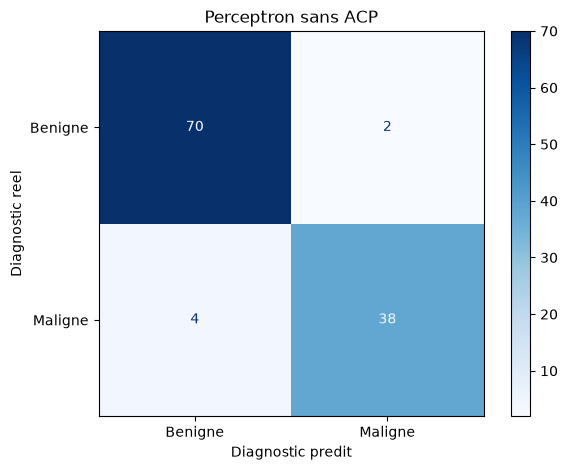


Perceptron avec ACP
              precision    recall  f1-score   support

     Benigne       0.97      0.99      0.98        72
     Maligne       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



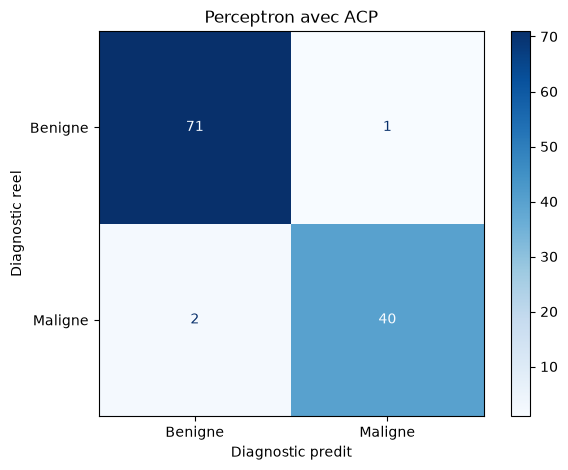

In [16]:
perceptron_predictions = [
    ("Perceptron sans ACP", y_pred),
    ("Perceptron avec ACP", y_pred_p),
]

for model_name, predictions in perceptron_predictions:
    print(f"\n{model_name}")
    print(classification_report(
        y_test, predictions, labels=[0, 1],
        target_names=["Benigne", "Maligne"], zero_division=0,
    ))
    matrix = confusion_matrix(y_test, predictions, labels=[0, 1])
    ConfusionMatrixDisplay(matrix, display_labels=["Benigne", "Maligne"]).plot(cmap="Blues")
    plt.xlabel("Diagnostic predit")
    plt.ylabel("Diagnostic reel")
    plt.title(model_name)
    plt.tight_layout()
    plt.show()

### 6.6. Comparer avec la regression logistique

La regression logistique est un autre modele de classification. Malgre son nom, elle peut predire ici benin ou malin. Elle apprend des poids autrement que le perceptron; elle n'est pas automatiquement le meilleur modele.

On l'entraine sur les memes exemples, avec et sans ACP, puis on utilise le meme test pour comparer les quatre configurations. On lit les rapports et les matrices de la meme facon.


Regression logistique sans ACP
              precision    recall  f1-score   support

     Benigne       0.96      0.99      0.97        72
     Maligne       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



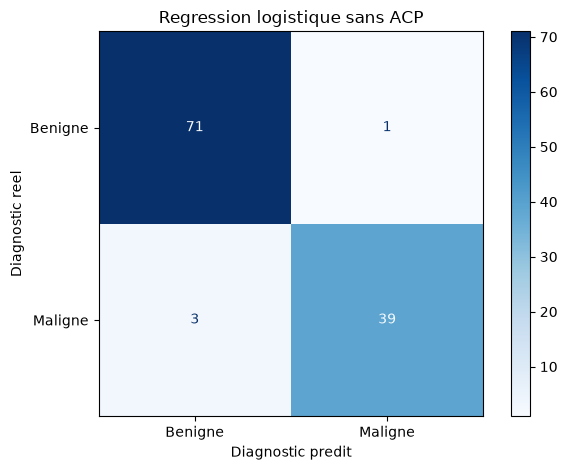


Regression logistique avec ACP
              precision    recall  f1-score   support

     Benigne       0.96      1.00      0.98        72
     Maligne       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



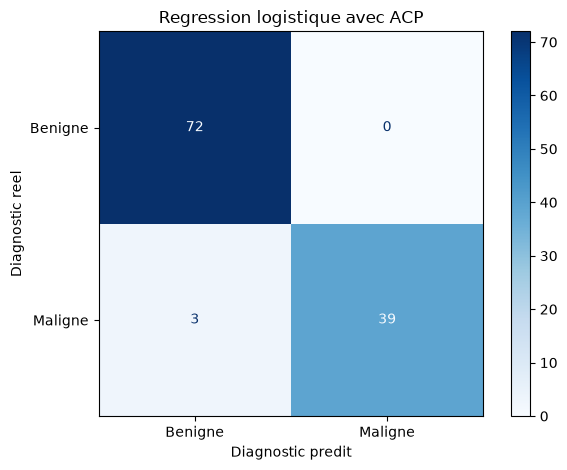

In [17]:
lr = LogisticRegression().fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

lr_p = LogisticRegression().fit(X_train_p, y_train)
y_pred_lr_p = lr_p.predict(X_test_p)

logistic_predictions = [
    ("Regression logistique sans ACP", y_pred_lr),
    ("Regression logistique avec ACP", y_pred_lr_p),
]

for model_name, predictions in logistic_predictions:
    print(f"\n{model_name}")
    print(classification_report(
        y_test, predictions, labels=[0, 1],
        target_names=["Benigne", "Maligne"], zero_division=0,
    ))
    matrix = confusion_matrix(y_test, predictions, labels=[0, 1])
    ConfusionMatrixDisplay(matrix, display_labels=["Benigne", "Maligne"]).plot(cmap="Blues")
    plt.xlabel("Diagnostic predit")
    plt.ylabel("Diagnostic reel")
    plt.title(model_name)
    plt.tight_layout()
    plt.show()

### 6.7. Comparer les resultats sans oublier les limites

Le tableau regroupe les quatre modeles sur le meme test. Le rappel malin indique la proportion des vrais cas malins retrouves. Les cas malins manques et les fausses alertes expliquent les erreurs cachees par un score global.

Un bon score sur ce seul tirage ne prouve ni une superiorite generale de l'ACP ni une fiabilite medicale. Pour choisir et regler un modele, on utilise une validation sur l'apprentissage (par exemple une validation croisee), puis un test final reserve. Comme l'EDA a deja examine l'ensemble des donnees, cette comparaison reste exploratoire.

In [18]:
comparison_rows = []

for model_name, predictions in perceptron_predictions + logistic_predictions:
    matrix = confusion_matrix(y_test, predictions, labels=[0, 1])
    comparison_rows.append({
        "Modele": model_name,
        "Bonnes reponses (%)": round(np.mean(predictions == y_test) * 100, 1),
        "Rappel malin (%)": round(matrix[1, 1] / matrix[1].sum() * 100, 1),
        "Cas malins manques": int(matrix[1, 0]),
        "Fausses alertes": int(matrix[0, 1]),
    })

comparison = pd.DataFrame(comparison_rows).set_index("Modele")
display(comparison)

,Bonnes reponses (%),Rappel malin (%),Cas malins manques,Fausses alertes
Modele,,,,
Perceptron sans ACP,94.7,90.5,4,2
Perceptron avec ACP,97.4,95.2,2,1
Regression logistique sans ACP,96.5,92.9,3,1
Regression logistique avec ACP,97.4,92.9,3,0
